In [2]:
import pandas as pd
import numpy as np
import os
import json
from scipy import constants
from pysr import PySRRegressor
import matplotlib.pyplot as plt
import sympy
import random
from ase.io import read

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [3]:
atoms_train = read("/home/paolo/Na_dataset/train_Na_new.xyz", index=":")
atoms_test = read("/home/paolo/Na_dataset/test_Na_new.xyz", index=":")

In [4]:
data_train = pd.concat(
    [pd.DataFrame([a.info for a in atoms_train]),
     pd.DataFrame({'volume': [a.get_volume() for a in atoms_train]})],
    axis=1
)
data_test = pd.concat(
    [pd.DataFrame([a.info for a in atoms_test]),
     pd.DataFrame({'volume': [a.get_volume() for a in atoms_test]})],
    axis=1
)

In [5]:
data_train

,Ea,B,N,O,F,Na,Al,Si,P,S,...,face-area-max,face-area-avg,face-area-min,face-area-count,pockets-per-ion,pockets-per-volume,paths-per-ion,paths-per-volume,poly_dist_avg_fixed,volume
0,0.365113,0.000000,0.0,0.631387,0.000000,0.127737,0.000000,0.000000,0.171533,0.000000,...,10.973040,2.521378,2.554994e-06,24.784055,5.371429,0.046887,45.342857,0.395793,0.385197,16038.697093
1,0.425024,0.000000,0.0,0.467925,0.000000,0.184906,0.000000,0.000000,0.135849,0.000000,...,11.777366,2.837638,8.278834e-07,29.008265,1.173469,0.011507,5.484694,0.053782,0.375974,19988.125341
2,0.274638,0.113043,0.0,0.000000,0.000000,0.208696,0.108696,0.000000,0.000000,0.304348,...,15.033404,3.383426,2.368494e-11,39.474009,2.583333,0.021100,14.566667,0.118978,0.080752,29383.692649
3,0.324737,0.000000,0.0,0.000000,0.000000,0.101124,0.000000,0.243446,0.033708,0.621723,...,12.877547,3.444336,5.345359e-06,40.587672,8.425926,0.032273,51.564815,0.197504,0.116010,28196.892709
4,0.345059,0.000000,0.0,0.407692,0.000000,0.219231,0.000000,0.000000,0.161538,0.000000,...,15.090982,3.165906,4.092372e-09,35.067899,2.105263,0.021466,13.359649,0.136222,0.363843,22360.631045
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1036,0.321759,0.000000,0.0,0.000000,0.000000,0.241935,0.000000,0.000000,0.161290,0.451613,...,12.864103,3.268545,4.741584e-07,37.803003,1.360784,0.012972,5.980392,0.057011,0.091131,26749.291087
1037,0.389788,0.000000,0.0,0.380711,0.106599,0.335025,0.177665,0.000000,0.000000,0.000000,...,8.761876,1.934795,1.569696e-06,12.466122,0.335859,0.008334,2.255051,0.055958,0.317510,15958.495344
1038,0.393305,0.250000,0.0,0.500000,0.000000,0.250000,0.000000,0.000000,0.000000,0.000000,...,8.829005,1.864119,7.645468e-07,13.897762,0.412000,0.008600,1.924000,0.040160,0.368284,11977.043019
1039,0.335168,0.000000,0.0,0.417969,0.000000,0.187500,0.000000,0.000000,0.027344,0.000000,...,13.544451,2.987695,7.102955e-06,32.194261,3.026042,0.029022,16.453125,0.157799,0.301010,20019.155151


In [7]:
def initialize(df, med_flag = False):
    kb = constants.physical_constants['Boltzmann constant in eV/K'][0]
    T = 300
    ln_D_all = np.array(df['logD'])
    if (med_flag == True):
        med =  np.median(ln_D_all).round()
        ln_D = ln_D_all[ln_D_all>med]
        ind = np.where(ln_D_all > med)[0]
    else:
        med = -100
        ln_D = ln_D_all[ln_D_all>med]
        ind = np.where(ln_D_all > med)[0]
    
    return {
        "ln_D_all" : ln_D_all,
        "ln_D" : ln_D,
        "T" : np.repeat(T, len(ln_D_all)),
        "E_T" : np.array(df['Ea'], dtype = 'float')[ind]/(kb*T),
        "E" : np.array(df['Ea'], dtype = 'float')[ind],
        "V" : np.array(df['volume'], dtype = 'float')[ind],
        
        # Atomic fractions of a given element
        "B":  np.array(df['B'], dtype='float')[ind],
        "N":  np.array(df['N'], dtype='float')[ind],
        "O":  np.array(df['O'], dtype='float')[ind],
        "F":  np.array(df['F'], dtype='float')[ind],
        "Na": np.array(df['Na'], dtype='float')[ind],
        "Al": np.array(df['Al'], dtype='float')[ind],
        "Si": np.array(df['Si'], dtype='float')[ind],
        "P":  np.array(df['P'], dtype='float')[ind],
        "S":  np.array(df['S'], dtype='float')[ind],
        "Cl": np.array(df['Cl'], dtype='float')[ind],
        "Ge": np.array(df['Ge'], dtype='float')[ind],
        "Br": np.array(df['Br'], dtype='float')[ind],
        "I":  np.array(df['I'], dtype='float')[ind],

        # Density in g/A^3
        "density": np.array(df['density'], dtype='float')[ind]*10**(-24),
        # Average Atomic Volume
        "AAV": np.array(df['AAV'], dtype='float')[ind],
        # Packing fraction
        "PF": np.array(df['PF'], dtype='float')[ind],
        # set-of-non-Na-atoms bond ionicity
        "SBI": np.array(df['SBI'], dtype='float')[ind],
        # Volume per anion
        "VPA": np.array(df['VPA'], dtype='float')[ind],
        # Na bond ionicity
        "NBI": np.array(df['NBI'], dtype='float')[ind],
        # Ratio of NBI and SBI
        "RBI": np.array(df['RBI'], dtype='float')[ind],
        # Weighted electronegativity
        "WE": np.array(df['weighted_electronegativity'], dtype='float')[ind],
        # -Na-Na (are just the Na-Na distances)
        "Na-Na": np.array(df['Na-Na'], dtype='float')[ind],
        "Na-Na-max": np.array(df['Na-Na-max'], dtype='float')[ind],
        "Na-Na-avg": np.array(df['Na-Na-avg'], dtype='float')[ind],
        # -bottleneck (free distance available for a Na⁺ ion to pass through the narrowest part of a diffusion pathway formed by surrounding framework atoms (typically O²⁻, S²⁻, or halides))
        "bottleneck_min": np.array(df['bottleneck_min'], dtype='float')[ind],
        "bottleneck_avg": np.array(df['bottleneck_avg'], dtype='float')[ind],
        # -poly_dist (Polyhedral distortion is the degree to which the bond lengths and bond angles of a coordination polyhedron differ from those of an ideal reference polyhedron.)
        "poly_dist_max": np.array(df['poly_dist_max'], dtype='float')[ind],
        "poly_dist_std": np.array(df['poly_dist_std'], dtype='float')[ind],
        "poly_dist_avg": np.array(df['poly_dist_avg'], dtype='float')[ind],
        "poly_dist_avg_fixed": np.array(df['poly_dist_avg_fixed'], dtype='float')[ind],
        # -face-area   (area of the shared face between two neighboring Voronoi polyhedra corresponding to adjacent Na sites it represents the cross-sectional area available for Na⁺ migration between those sites)
        "face-area-max": np.array(df['face-area-max'], dtype='float')[ind],
        "face-area-avg": np.array(df['face-area-avg'], dtype='float')[ind],
        "face-area-min": np.array(df['face-area-min'], dtype='float')[ind],
        "face-area-count": np.array(df['face-area-count'], dtype='float')[ind],
        # -pockets  (free-volume region in the crystal structure where a Na⁺ ion can reside with relatively low energy, typically corresponding to a stable or metastable Na site)
        "pockets-per-ion": np.array(df['pockets-per-ion'], dtype='float')[ind],
        "pockets-per-volume": np.array(df['pockets-per-volume'], dtype='float')[ind],
        # -paths  (connected sequence of pockets linked by Voronoi faces and constrained by bottlenecks, forming a continuous route that allows Na⁺ ions to move through the crystal lattice)
        "paths-per-ion": np.array(df['paths-per-ion'], dtype='float')[ind],
        "paths-per-volume": np.array(df['paths-per-volume'], dtype='float')[ind],
    }

In [15]:
kb = constants.physical_constants['Boltzmann constant in eV/K'][0]
data = initialize(data_train)
lnDvsE = pd.DataFrame({
    "sample_id": [f"s{j+1}" for j in range(len(data['ln_D']))], 
    "E_T": data['E_T'],
    "rho": (data['density'] - data['density'].mean()) / data['density'].std(),
    "AAV": data['AAV'],
    "PF": data['PF'],
    "VPA": data['VPA'],
    "NBI": data['NBI'],
    "SBI": data['SBI'],
    "RBI": data['RBI'],
    "WE": data['WE'],
    "B": data['B'],
    "N": data['N'],
    "S": data['S'],
    "O": data['O'],
    "F": data['F'],
    "Na": data['Na'],
    "Al": data['Al'],
    "Si": data['Si'],
    "P": data['P'],
    "Cl": data['Cl'],
    "Ge": data['Ge'],
    "Br": data['Br'],
    "I": data['I'],

    # Volume
    "cub_root_V" : data['V']**(1/3),
    
    # Na–Na distances
    "Na-Na ": data['Na-Na'],
    "Na-Na-max": data['Na-Na-max'],
    "Na-Na-avg": data['Na-Na-avg'],

    # Bottleneck descriptors
    "bottleneck_min": data['bottleneck_min'],
    "bottleneck_avg": data['bottleneck_avg'],

    # Polyhedral distortion
    "poly_dist_max": data['poly_dist_max'],
    "poly_dist_std": data['poly_dist_std'],
    "poly_dist_avg": data['poly_dist_avg'],
    "poly_dist_avg_fixed": data['poly_dist_avg_fixed'],

    # Voronoi face areas
    "face-area-max": data['face-area-max'],
    "face-area-avg": data['face-area-avg'],
    "face-area-min": data['face-area-min'],
    "face-area-count": data['face-area-count'],

    # Pockets
    "pockets-per-ion": data['pockets-per-ion'],
    "pockets-per-volume": data['pockets-per-volume'],

    # Paths
    "paths-per-ion": data['paths-per-ion'],
    "paths-per-volume": data['paths-per-volume'],

    # Target
    "ln_D": data['ln_D']
})

In [16]:
n_feat = 40
lnDvsE.to_csv(f"/home/paolo/Thesis/Na/data/desc_dim/Na_lndiff{n_feat}_temp300_withunits2.csv", index=False)
data_file = f"/home/paolo/Thesis/Na/data/desc_dim/Na_lndiff{n_feat}_temp300_withunits2.csv"
os.environ["SISSOPP_TUT_DAT_FILE"] = data_file

In [10]:
# Try the fit with the exact functional form
rung = 1
desc_dim = 3
Diff_json = {
    'data_file': data_file,
     'property_key': 'ln_D',
     'desc_dim': desc_dim,
     'n_sis_select': 10,
     'max_rung': rung,
     'calc_type': 'regression',
     'min_abs_feat_val': 1e-05,
     'max_abs_feat_val': 1e8,
     'n_residual': 10,
     'n_models_store': 10,
     'leave_out_frac': 0.0,
     'leave_out_inds': [],
     'opset': ['exp', 'add', 'sub', 'mult', 'div', 'sin', 'cos']
}
json.dump(Diff_json, open(f"/home/paolo/Thesis/Na/data/desc_dim/lndiff{n_feat}_{rung}_{desc_dim}_withunits2.json", "w"), indent=4)

In [ ]:
# Rung=1 desc_dim=2 Features=40 'E_T': E/(kb*T), 'rho': density, 'AAV': AAV, 'PF': PF, 'VPA': VPA, 'NBI': NBI, 'SBI': SBI,  'RBI': RBI, 'WE': WE, 
        # 'B': B, 'N': N, 'S': S, 'O': O, 'F': F, 'Na': Na, 'Al': Al, 'Si': Si, 'P': P, 'Cl': Cl, 'Ge': Ge, 'Br': Br, 'I': I, 'cub_root_V': V^(1/3),
        # "Na-Na": data['Na-Na'], "Na-Na-max": data['Na-Na-max'], "Na-Na-avg": data['Na-Na-avg'], "bottleneck_min": data['bottleneck_min'], "bottleneck_avg": data['bottleneck_avg'],
        # "poly_dist_max": data['poly_dist_max'], "poly_dist_std": data['poly_dist_std'], "poly_dist_avg": data['poly_dist_avg'], "poly_dist_avg_fixed": data['poly_dist_avg_fixed'],
        # "face-area-max": data['face-area-max'], "face-area-avg": data['face-area-avg'], "face-area-min": data['face-area-min'], "face-area-count": data['face-area-count'],
        # "pockets-per-ion": data['pockets-per-ion'], "pockets-per-volume": data['pockets-per-volume'],
        # "paths-per-ion": data['paths-per-ion'], "paths-per-volume": data['paths-per-volume'],
# time input_parsing: 0.0462261 s
# Time to generate feat space: 0.0178483 s
# Projection time: 0.0011811 s
# Time to get best features on rank : 8.56e-05 s
# |---Complete final combination/selection from all ranks: 0.0003616 s
# Time for SIS: 0.0021455 s
# Time for l0-norm: 0.0119904 s
# Projection time: 0.0064893 s
# Time to get best features on rank : 7.58e-05 s
# |---Complete final combination/selection from all ranks: 0.0003133 s
# Time for SIS: 0.0084202 s
# Time for l0-norm: 0.0057841 s
# Projection time: 0.0041251 s
# Time to get best features on rank : 7.84e-05 s
# |---Complete final combination/selection from all ranks: 0.0003043 s
# Time for SIS: 0.0066147 s
# Time for l0-norm: 0.023659 s
# Train RMSE: 0.545016 Unitless
# c0 + a0 * (E_T / cub_root_V)

# Train RMSE: 0.451406 Unitless
# c0 + a0 * (face-area-avg * E_T) + a1 * (O + E_T)

# Train RMSE: 0.357854 Unitless
# c0 + a0 * (face-area-avg * NBI) + a1 * (Al + O) + a2 * (O + E_T)
# Coefficients
# Task   a0                      a1                      a2                      c0
# all ,  1.469851661171671e+00, -2.745211996193482e+00, -7.516376199737155e-01, -1.187256912695403e+01, 


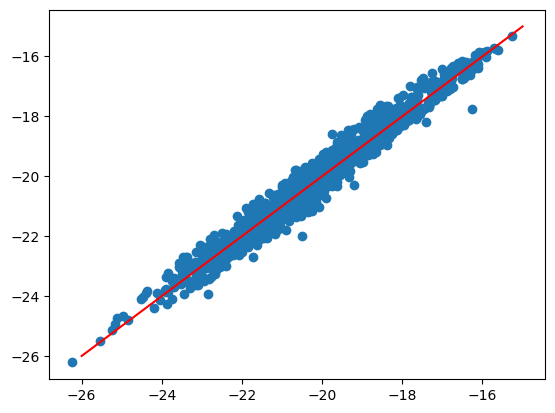

In [19]:
data = initialize(data_train)
a0 =  1.469851661171671e+00
a1 =  -2.745211996193482e+00
a2 =  -7.516376199737155e-01
c0 = -1.187256912695403e+01
fct = c0 + a0 * (data['NBI'] * data['face-area-avg']) + a1 * (data['O'] + data['Al']) + a2 * (data['O'] + data['E_T'])
plt.scatter(fct, data['ln_D'])
plt.plot([-26,-15], [-26, -15], color = 'red')
plt.show()

In [13]:
def extract_dd3(ms = 10, rung=1, feat = 40):
    '''Extract the formulas and the values of the parameters from the SISSO output for desc_dim=3'''
    dd = 3
    formulas = []
    a0_list = []
    a1_list = []
    a2_list = []
    c0_list = []
    models_stored = ms
    for i in range(models_stored):
        filename = f'/home/paolo/Thesis/Na/data/desc_dim/models_lndiff{feat}_{rung}_{dd}_withunits/train_dim_{dd}_model_{i}.dat'
        with open(filename, 'r') as f:
            line1 = next(f)               # First line
            for _ in range(4): next(f)    # Skip lines 2 to 5
            line6 = next(f)               # Sixth line
            formula = line1.replace('#', '').strip()
            # Split line6 by spaces
            parts = line6.strip().split()
            a0_i = parts[3].rstrip(',')
            a1_i = parts[4].rstrip(',')
            a2_i = parts[5].rstrip(',')
            c0_i = parts[6].rstrip(',')
    
            formulas.append(formula)
            a0_list.append(a0_i)
            a1_list.append(a1_i)
            a2_list.append(a2_i)
            c0_list.append(c0_i)
            #print(formula, a0_i, a1_i, c0_i)
    return(formulas, a0_list, a1_list, a2_list, c0_list)

In [14]:
extract_dd3()

(['c0 + a0 * (face-area-avg * NBI) + a1 * (Al + O) + a2 * (O + E_T)',
  'c0 + a0 * (cub_root_V * WE) + a1 * (Al + O) + a2 * (O + E_T)',
  'c0 + a0 * (Al - B) + a1 * (face-area-avg * E_T) + a2 * (O + E_T)',
  'c0 + a0 * (Al + O) + a1 * (face-area-avg / E_T) + a2 * (O + E_T)',
  'c0 + a0 * (cub_root_V * WE) + a1 * (O / RBI) + a2 * (O + E_T)',
  'c0 + a0 * (F + B) + a1 * (E_T / cub_root_V) + a2 * (AAV / E_T)',
  'c0 + a0 * (PF / NBI) + a1 * (O / RBI) + a2 * (O + E_T)',
  'c0 + a0 * (PF / NBI) + a1 * (Al + O) + a2 * (O + E_T)',
  'c0 + a0 * (face-area-avg * NBI) + a1 * (O / RBI) + a2 * (O + E_T)',
  'c0 + a0 * (O / RBI) + a1 * (face-area-avg / E_T) + a2 * (O + E_T)'],
 ['1.469851661171671e+00',
  '4.958142587923720e-02',
  '-2.114947700136517e+00',
  '-1.880348423645656e+00',
  '4.454950806590404e-02',
  '2.983870495237329e+00',
  '-1.315820150440753e+00',
  '-1.371397419747213e+00',
  '1.286036470669287e+00',
  '-3.422104364579746e+00'],
 ['-2.745211996193482e+00',
  '-2.965534012958087e+

In [12]:
extract_dd3()

(['c0 + a0 * (face-area-avg * NBI) + a1 * (Al + O) + a2 * (O + E_T)',
  'c0 + a0 * (cub_root_V * WE) + a1 * (Al + O) + a2 * (O + E_T)',
  'c0 + a0 * (Al - B) + a1 * (face-area-avg * E_T) + a2 * (O + E_T)',
  'c0 + a0 * (Al + O) + a1 * (face-area-avg / E_T) + a2 * (O + E_T)',
  'c0 + a0 * (cub_root_V * WE) + a1 * (O / RBI) + a2 * (O + E_T)',
  'c0 + a0 * (F + B) + a1 * (E_T / cub_root_V) + a2 * (AAV / E_T)',
  'c0 + a0 * (cub_root_V * WE) + a1 * (poly_dist_avg / RBI) + a2 * (O + E_T)',
  'c0 + a0 * (PF / NBI) + a1 * (O / RBI) + a2 * (O + E_T)',
  'c0 + a0 * (PF / NBI) + a1 * (Al + O) + a2 * (O + E_T)',
  'c0 + a0 * (cub_root_V * WE) + a1 * (poly_dist_avg_fixed / RBI) + a2 * (O + E_T)'],
 ['1.469851661171671e+00',
  '4.958142587923720e-02',
  '-2.114947700136517e+00',
  '-1.880348423645656e+00',
  '4.454950806590404e-02',
  '2.983870495237329e+00',
  '4.186487218713302e-02',
  '-1.315820150440753e+00',
  '-1.371397419747213e+00',
  '4.383846853888108e-02'],
 ['-2.745211996193482e+00',
  

# E vs Rest

In [22]:
kb = constants.physical_constants['Boltzmann constant in eV/K'][0]
data = initialize(data_train)
EvsRest = pd.DataFrame({
    "sample_id": [f"s{j+1}" for j in range(len(data['ln_D']))], 
    "rho (g/cm^3)": data['density'],
    "AAV (A^3)": data['AAV'],
    "PF": data['PF'],
    "VPA (A^3)": data['VPA'],
    "NBI": data['NBI'],
    "SBI": data['SBI'],
    "RBI": data['RBI'],
    "WE": data['WE'],
    "B": data['B'],
    "N": data['N'],
    "S": data['S'],
    "O": data['O'],
    "F": data['F'],
    "Na": data['Na'],
    "Al": data['Al'],
    "Si": data['Si'],
    "P": data['P'],
    "Cl": data['Cl'],
    "Ge": data['Ge'],
    "Br": data['Br'],
    "I": data['I'],

    # Volume
    "cub_root_V (A)" : data['V']**(1/3),
    
    # Na–Na distances
    "Na-Na (A)": data['Na-Na'],
    "Na-Na-max (A)": data['Na-Na-max'],
    "Na-Na-avg (A)": data['Na-Na-avg'],

    # Bottleneck descriptors
    "bottleneck_min (A)": data['bottleneck_min'],
    "bottleneck_avg (A)": data['bottleneck_avg'],

    # Polyhedral distortion
    "poly_dist_max": data['poly_dist_max'],
    "poly_dist_std": data['poly_dist_std'],
    "poly_dist_avg": data['poly_dist_avg'],
    "poly_dist_avg_fixed": data['poly_dist_avg_fixed'],

    # Voronoi face areas
    "face-area-max (A^2)": data['face-area-max'],
    "face-area-avg (A^2)": data['face-area-avg'],
    "face-area-min (A^2)": data['face-area-min'],
    "face-area-count": data['face-area-count'],

    # Pockets
    "pockets-per-ion": data['pockets-per-ion'],
    "pockets-per-volume (A^-3)": data['pockets-per-volume'],

    # Paths
    "paths-per-ion": data['paths-per-ion'],
    "paths-per-volume (A^-3)": data['paths-per-volume'],

    # Target
    "E (eV)": data['E']
})

In [23]:
n_feat = 39
EvsRest.to_csv(f"/home/paolo/Thesis/Na/data/desc_dim/Na_Ea{n_feat}_temp300_withunits.csv", index=False)
data_file = f"/home/paolo/Thesis/Na/data/desc_dim/Na_Ea{n_feat}_temp300_withunits.csv"
os.environ["SISSOPP_TUT_DAT_FILE"] = data_file

In [24]:
# Try the fit with the exact functional form
rung = 1
desc_dim = 3
Diff_json = {
    'data_file': data_file,
     'property_key': 'E',
     'desc_dim': desc_dim,
     'n_sis_select': 10,
     'max_rung': rung,
     'calc_type': 'regression',
     'min_abs_feat_val': 1e-05,
     'max_abs_feat_val': 1e8,
     'n_residual': 10,
     'n_models_store': 10,
     'leave_out_frac': 0.0,
     'leave_out_inds': [],
     'opset': ['exp', 'add', 'sub', 'mult', 'div', 'sin', 'cos']
}
json.dump(Diff_json, open(f"/home/paolo/Thesis/Na/data/desc_dim/Ea{n_feat}_{rung}_{desc_dim}_withunits.json", "w"), indent=4)

In [ ]:
# time input_parsing: 0.0443787 s
# Time to generate feat space: 0.0171525 s
# Projection time: 0.0012634 s
# Time to get best features on rank : 8.61e-05 s
# |---Complete final combination/selection from all ranks: 0.0003734 s
# Time for SIS: 0.0022545 s
# Time for l0-norm: 0.0041486 s
# Projection time: 0.0061839 s
# Time to get best features on rank : 7.82e-05 s
# |---Complete final combination/selection from all ranks: 0.0002974 s
# Time for SIS: 0.0081113 s
# Time for l0-norm: 0.0056609 s
# Projection time: 0.0045899 s
# Time to get best features on rank : 7.79e-05 s
# |---Complete final combination/selection from all ranks: 0.0003023 s
# Time for SIS: 0.0067895 s
# Time for l0-norm: 0.0247492 s
# Train RMSE: 0.034267 eV
# c0 + a0 * (face-area-count * face-area-max)

# Train RMSE: 0.0321761 eV
# c0 + a0 * (poly_dist_avg - SBI) + a1 * (face-area-count * face-area-max)

# Train RMSE: 0.0304895 eV
# c0 + a0 * (Ge * S) + a1 * (SBI - NBI) + a2 * (face-area-count * face-area-avg)
# Coefficients
# Task   a0                      a1                      a2                      c0
# all ,  4.261917926605502e-01, -1.321334713269502e-01, -7.944825917858859e-04,  3.615409540165300e-01, 

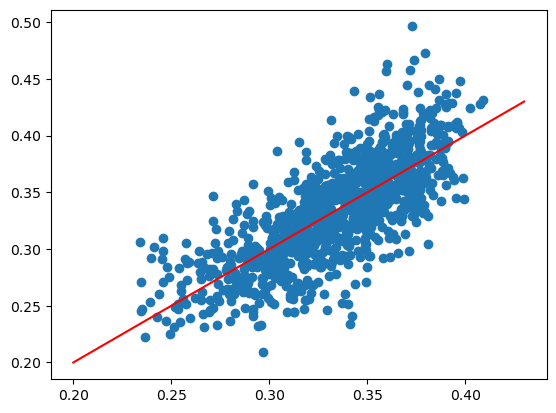

In [27]:
data = initialize(data_train)
a0 =  4.261917926605502e-01
a1 =  -1.321334713269502e-01
a2 =  -7.944825917858859e-04
c0 = 3.615409540165300e-01
fct = c0 + a0 * (data['Ge'] * data['S']) + a1 * (data['SBI'] - data['NBI']) + a2 * (data['face-area-count'] * data['face-area-avg'])
plt.scatter(fct, data['E'])
plt.plot([0.20,0.43], [0.20, 0.43], color = 'red')
plt.show()

In [25]:
def extract_dd3_Ea(ms = 10, rung=1, feat = 40):
    '''Extract the formulas and the values of the parameters from the SISSO output for desc_dim=3'''
    dd = 3
    formulas = []
    a0_list = []
    a1_list = []
    a2_list = []
    c0_list = []
    models_stored = ms
    for i in range(models_stored):
        filename = f'/home/paolo/Thesis/Na/data/desc_dim/models_Ea{feat}_{rung}_{dd}_withunits/train_dim_{dd}_model_{i}.dat'
        with open(filename, 'r') as f:
            line1 = next(f)               # First line
            for _ in range(4): next(f)    # Skip lines 2 to 5
            line6 = next(f)               # Sixth line
            formula = line1.replace('#', '').strip()
            # Split line6 by spaces
            parts = line6.strip().split()
            a0_i = parts[3].rstrip(',')
            a1_i = parts[4].rstrip(',')
            a2_i = parts[5].rstrip(',')
            c0_i = parts[6].rstrip(',')
    
            formulas.append(formula)
            a0_list.append(a0_i)
            a1_list.append(a1_i)
            a2_list.append(a2_i)
            c0_list.append(c0_i)
            #print(formula, a0_i, a1_i, c0_i)
    return(formulas, a0_list, a1_list, a2_list, c0_list)

In [26]:
extract_dd3_Ea()

(['c0 + a0 * (Ge * S) + a1 * (SBI - NBI) + a2 * (face-area-count * face-area-avg)',
  'c0 + a0 * (Ge * S) + a1 * (poly_dist_avg_fixed - SBI) + a2 * (face-area-count * face-area-avg)',
  'c0 + a0 * (poly_dist_avg - SBI) + a1 * (Ge * S) + a2 * (face-area-count * face-area-avg)',
  'c0 + a0 * (Ge * S) + a1 * (SBI - NBI) + a2 * (face-area-count * cub_root_V)',
  'c0 + a0 * (poly_dist_avg - SBI) + a1 * (Ge * S) + a2 * (face-area-count * cub_root_V)',
  'c0 + a0 * (Ge * S) + a1 * (poly_dist_avg_fixed - SBI) + a2 * (face-area-count * cub_root_V)',
  'c0 + a0 * (Ge * S) + a1 * (Na-Na / RBI) + a2 * (face-area-count * cub_root_V)',
  'c0 + a0 * (Ge * S) + a1 * (Na-Na / RBI) + a2 * (face-area-count * face-area-avg)',
  'c0 + a0 * (poly_dist_avg - SBI) + a1 * (Ge * S) + a2 * (face-area-count * Na-Na)',
  'c0 + a0 * (Ge * S) + a1 * (poly_dist_avg_fixed - SBI) + a2 * (face-area-count * face-area-max)'],
 ['4.261917926605502e-01',
  '4.312755927297620e-01',
  '1.279217290440420e-01',
  '4.39736091257